# This notebook walks through recording extracellular voltage using the simulator 

In [2]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [2]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build a cell, point to the params file of interest 

In [3]:
# Code to setup a single simulated RGC
# Default params file located at: 'cell_param_files/params_35.csv'
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')

After any change to cell geometry or nseg, be sure to invoke setpointers()


### Output simple facts: (x,y,z) of soma center and all compartments 

In [4]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center) # units: [um]

RGC.shift_cell_x_y_z(0,0,0)
print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [0.0, 0.0, 0.0]


In [5]:
# Code to traverse through all sections and segments of a cell. This is very
#  useful for debugging and probing different features (membrane voltage, 
#  currents, channel dynamics) at each segment. It also helps to understand 
#  how the cell is layed out in space. 
for sec in RGC.section_list: 
    for seg in sec:
        print(seg)
        print('Segment coordinates: ', seg.x_xtra, seg.y_xtra, seg.z_xtra)

Cell[0].soma(0.1)
Segment coordinates:  0.0 0.0 -8.0
Cell[0].soma(0.3)
Segment coordinates:  0.0 0.0 -3.999999999999999
Cell[0].soma(0.5)
Segment coordinates:  0.0 0.0 2.220446049250313e-15
Cell[0].soma(0.7)
Segment coordinates:  0.0 0.0 4.000000000000002
Cell[0].soma(0.9)
Segment coordinates:  0.0 0.0 8.0
Cell[0].dend[0](0.125)
Segment coordinates:  8.244684656136952 4.3437302051977404 -4.9695614754626245
Cell[0].dend[0](0.375)
Segment coordinates:  6.254054426174526 8.931190710960653 -10.908684426387872
Cell[0].dend[0](0.625)
Segment coordinates:  4.129450511405039 13.615720913606317 -16.601027853265297
Cell[0].dend[0](0.875)
Segment coordinates:  -0.36188830850202386 19.38462634076912 -17.39469860944437
Cell[0].dend[50](0.5)
Segment coordinates:  -4.945000171661377 19.614999771118164 -17.5
Cell[0].dend[52](0.25)
Segment coordinates:  -8.250492630372461 16.439785067507984 -17.5
Cell[0].dend[52](0.75)
Segment coordinates:  -11.842476772282906 13.165312943882286 -17.5
Cell[0].dend[54](

## Step 2: Setup electrical stimulus 

In [6]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = 2.5 # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-10,0,40]] # units: [um] 
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

## Step 3: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [7]:
# Let's record all capacitive and ionic currents, along with membrane voltage
data = {}
for section in RGC.section_list:
    data[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        # record membrane voltage
        data[section.name()]['vmem' + str(i)] = h.Vector().record(seg._ref_v)
        # record total transmembrane currents
        data[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane)
        # record capacitive current
        data[section.name()]['icap' + str(i)] = h.Vector().record(seg._ref_i_cap)
        # record Na, K, and Ca currents
        data[section.name()]['ina' + str(i)] = h.Vector().record(seg._ref_ina)
        data[section.name()]['ik' + str(i)] = h.Vector().record(seg._ref_ik)
        data[section.name()]['ica' + str(i)] = h.Vector().record(seg._ref_ica)

In [8]:
# # Setup dictionary to capture iOut at all cell compartments
# iOut = {}
# h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
# for section in RGC.section_list:
#     iOut[section.name()] = {}
#     for seg, i in zip(section,range(section.nseg)):
#         iOut[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Time vector

In [9]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

## Step 4: Apply stimulus to the cell! (Run only one cell below)

In [10]:
# First, decide if you want current clamp (visually-) or electrode 
#   current (extracellularly-) evoked spiking
stim_type = 'clamp' # 'clamp' or 'extra'

In [23]:
if stim_type == 'clamp':
    # Current clamp simulation
    h.init()
    h.v_init = -69.2 # Old = -70
    h.finitialize(h.v_init)
    h.fcurrent()
    h.dt = 0.005
    h.tstop = 40

    # # Create intracellular stimulus
    # CurrentClamp = h.IClamp(0.5,sec=RGC.cell.soma) # inject current to soma
    # # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    # CurrentClamp.delay= 1 # msec
    # CurrentClamp.dur= 0.15 # msec
    # CurrentClamp.amp= 3.9 # nA

    # Create intracellular stimulus
    CurrentClamp = h.IClamp(0.5,sec=RGC.cell.soma) # inject current to soma
    # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    CurrentClamp.delay= 10 # msec
    CurrentClamp.dur= 0.30 # msec
    CurrentClamp.amp= 4 # nA

    # run sim!
    h.run()
elif stim_type == 'extra':
    # Need to do this everytime the stimulus parameters are changed
    hf.setupTransferImpedance(Stim, RGC)

    # Play the stimulus into the cell, setting it up for stimulation
    Stim['amp'] = Stim['polarity']*Stim['amp']
    tsvec, isvec = hf.setupStimulus(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    # Initialization phase of the simulation 
    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    # Run the simulation 
    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)
    print('***** sim done *****')

## Step 5: Visualize what happened

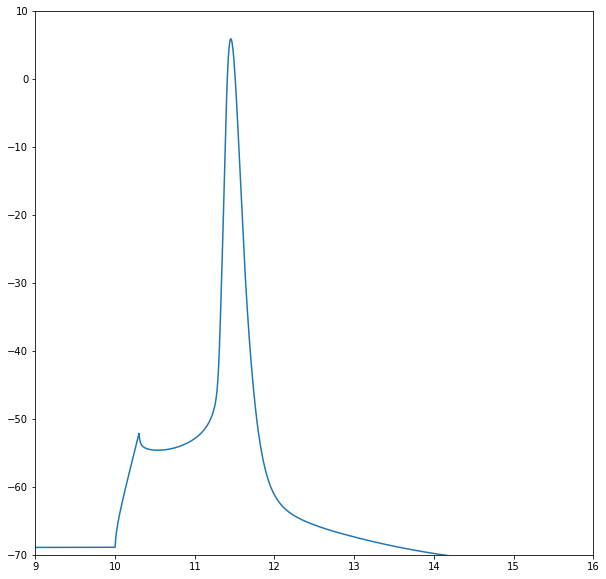

In [24]:
# Let's plot the membrane voltage at the middle of the axon
fig, ax1 = plt.subplots(1,1,figsize=(10,10))

# First, extract vmem from middle of soma
time = t 
soma_vmem = data['Cell[0].soma']['vmem4']
ax1.plot(time,soma_vmem)

# soma_ina = data['Cell[0].axon']['ina201']
# soma_ik = data['Cell[0].axon']['ik201']
# soma_ica = data['Cell[0].axon']['ica201']
# # soma_icap = data['Cell[0].axon']['icap201']
# # soma_imem = data['Cell[0].axon']['imem201']
# ax2.plot(time,soma_ina)
# ax2.plot(time,soma_ik)
# ax2.plot(time,soma_ica)
# # ax2.plot(time,soma_icap)
# ax2.plot(time,soma_imem)
ax1.set_ylim([-70,10])
ax1.set_xlim([9,16])
# ax2.set_xlim([10,20])

# save plot as pdf
plt.savefig("AP_success.pdf",format="pdf", bbox_inches="tight")

plt.show()

In [17]:
print(soma_vmem[-1])

-69.23987882635025
